In [99]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Specify each path

In [100]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.hdf5'
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

# Set number of classes

In [101]:
NUM_CLASSES = 7

# Dataset reading

In [102]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 4)))

In [103]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.8, random_state=RANDOM_SEED)

# Model building

In [105]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2 + 3, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [106]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout_10 (Dropout)        (None, 45)                0         
                                                                 
 dense_15 (Dense)            (None, 20)                920       
                                                                 
 dropout_11 (Dropout)        (None, 20)                0         
                                                                 
 dense_16 (Dense)            (None, 10)                210       
                                                                 
 dense_17 (Dense)            (None, 7)                 77        
                                                                 
Total params: 1,207
Trainable params: 1,207
Non-trainable params: 0
_________________________________________________________________


In [107]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [108]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [109]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
12/15 [=======================>......] - ETA: 0s - loss: 2.0652 - accuracy: 0.1361 
Epoch 1: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
15/15 [==============================] - 1s 39ms/step - loss: 2.0476 - accuracy: 0.1423 - val_loss: 1.9456 - val_accuracy: 0.1395
Epoch 2/1000
12/15 [=======================>......] - ETA: 0s - loss: 1.9835 - accuracy: 0.1497
Epoch 2: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
15/15 [==============================] - 0s 16ms/step - loss: 1.9776 - accuracy: 0.1536 - val_loss: 1.9167 - val_accuracy: 0.2082
Epoch 3/1000
14/15 [===========================>..] - ETA: 0s - loss: 1.9419 - accuracy: 0.1769
Epoch 3: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
15/15 [==============================] - 0s 13ms/step - loss: 1.9425 - accuracy: 0.1751 - val_loss: 1.9018 - val_accuracy: 0.2747
Epoch 4/1000
13/15 [=========================>....] - ETA: 0s - loss: 1.9197 - accuracy: 0.19

In [110]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

4/4 [==============================] - 0s 3ms/step - loss: 0.5219 - accuracy: 0.8498


In [111]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [112]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

[1.73196942e-03 3.46035638e-04 1.11841786e-04 5.04627300e-04
 2.22433936e-02 2.26319134e-01 7.48742998e-01]
6


# Confusion matrix

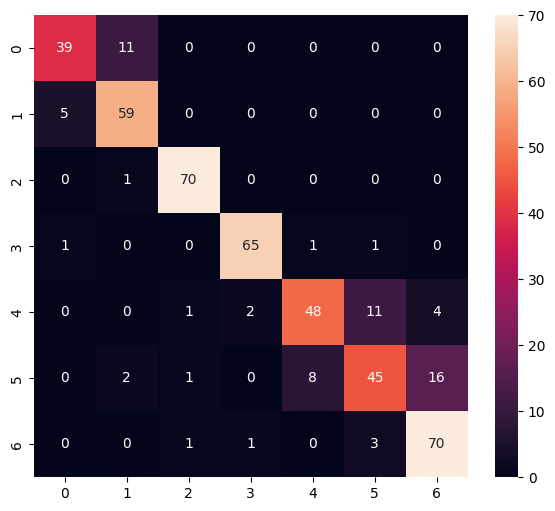

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.78      0.82        50
           1       0.81      0.92      0.86        64
           2       0.96      0.99      0.97        71
           3       0.96      0.96      0.96        68
           4       0.84      0.73      0.78        66
           5       0.75      0.62      0.68        72
           6       0.78      0.93      0.85        75

    accuracy                           0.85       466
   macro avg       0.85      0.85      0.85       466
weighted avg       0.85      0.85      0.85       466



In [113]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [114]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)

In [115]:
# Transform model (quantization)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\zoric\AppData\Local\Temp\tmpyobwiw1_\assets


INFO:tensorflow:Assets written to: C:\Users\zoric\AppData\Local\Temp\tmpyobwiw1_\assets


6700

# Inference test

In [116]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [117]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [118]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [119]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 0 ns


In [120]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[1.7319709e-03 3.4603613e-04 1.1184189e-04 5.0462806e-04 2.2243405e-02
 2.2631910e-01 7.4874300e-01]
6
